In [1]:
# data analysis and wrangling
import pandas as pd
import numpy as np
import random as rnd

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier

In [1]:
train_df = pd.read_csv(r'C:\Users\Alex\Documents\MyJupyter\Portfolio_Projects\Datasets\P_1_titanic_dataset\train.csv')
test_df = pd.read_csv(r'C:\Users\Alex\Documents\MyJupyter\Portfolio_Projects\Datasets\P_1_titanic_dataset\test.csv')
combine = [train_df, test_df]

# Используем переменную - combine - объединяем датасеты - важно для предобработки, чтобы не обрабатывать
# данные по отдельности, чтобы потом не было нестыковок. 

In [3]:
print(train_df.columns.values)

# смотрим какие фичи у нас в данных. 

['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']


In [2]:
train_df.head()

# Смотрим на данные. Обращаем внимание, какие фичи у нас категориальные а какие количественные. 
# Категориальные: Survived, Sex, and Embarked. 
# Порядковые: Pclass. 
# Количественные:  
    # Непрерывные: Age, Fare. 
    # Дискретные: SibSp, Parch.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#  Также смотрим есть ли у нас фичи смешанных типов. Например фичи ticket/cabin - являются смешанными, а именно буквенно-цифравыми
# Это первые кандидаты на корректировку

# Есть ли фичи с проркускми, пустыми ячейками или значениями - null?
train_df.isnull().sum()

# Cabin-Age-Embarked - в тренировочных данных присутсвтвуют пропуски
# Cabin-Age - в тестовых данных являются неполными

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Фичи каких типов у нас в Датасетех?
train_df.info()
print('_'*40)    # горизонтальная линия для улучшения читаемости
test_df.info()

# 7 количественных фич (в тестовых - 6): int и float 
# 5 качественных: Object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passenger

In [7]:
# Посмотрим как распределяются кооличественные фичи

train_df.describe()

    # Исзодя из данной статичтической сводки количественных фич, можно сделать несколько утверждений:
# Средний возрась пассажиров = 30лет, максимальный=80, минимальный=0.4
# более 75% пассажиров были без родителей или детей (Parch)
# менее 1% пассажиров заплатили за билет 512$
# менее 1% пассажиров входит в возрастную групппу 65-80 лет

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Посмотрим как распределяются категориальные фичи

train_df.describe(include=['O'])   # include=['O'] - распределение кат.фич (Object)

# Все имена в данных - уникальные
# 65% пассажиров - мужчины (top=male, freq=577/count=891).
# Либо значения для - cabin - повторяются, либо в одной каюте проживало несколько пассажиров
# Фича - Embarked - принимает 3 значения. Значение 'S' - самое частое их всех
# Значение дял фичи - Ticket - повторяются в 23% случаев (unique/count)

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


# ВЫДВИГАЕМ ГИПОТЕЗЫ

In [9]:
train_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [10]:
train_df[['Sex', 'Survived']].groupby('Sex', as_index=False).mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [11]:
train_df[['SibSp', 'Survived']].groupby('SibSp', as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [12]:
train_df[['Parch', 'Survived']].groupby('Parch', as_index=False).mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


# АНАЛИЗ КОРРЕЛЯЦИЙ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

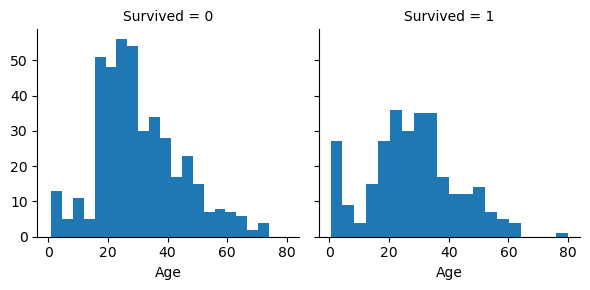

In [13]:
g = sns.FacetGrid(train_df, col='Survived')
g.map(plt.hist, 'Age', bins=20)

plt.show()

# sns.FacetGrid - создает сетку для определенного признака(Survived) для каждой категории (0/1)
# g.map(plt.hist, 'Age', bins=20) - для каждой созданной сетки строится гистограмма. 
# 'Age' - столбец, для которого будет построена гистограмма. 
# bins=20 - Кол-во столбцов на гистограмме. Возраст будет разделен на 20 интервалов

                                Корреляция Количественных и Порядковых признакаков с Цлелевой Переменной 
                                                (Age/Pclass - Survived)

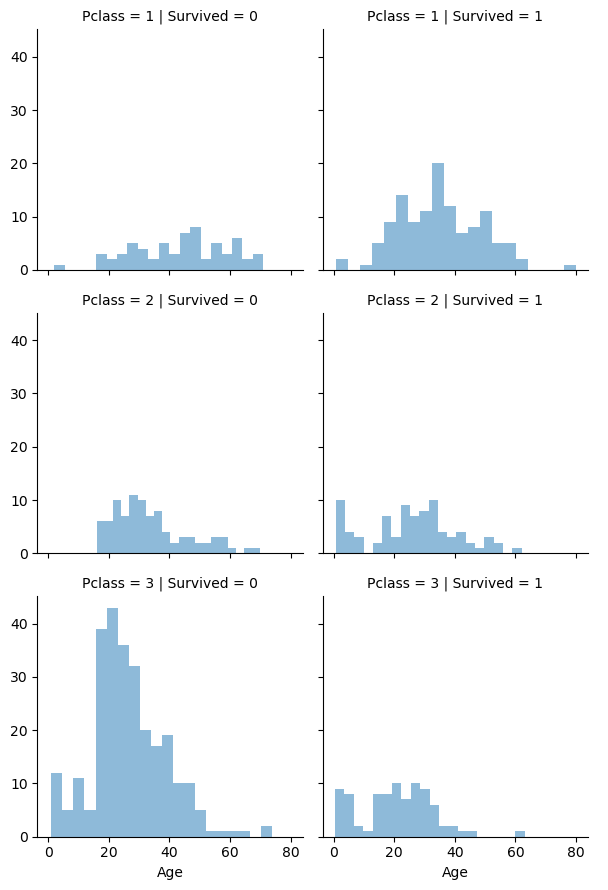

In [14]:
# grid = sns.FacetGrid(train_df, col='Pclass', hue='Survived')
grid = sns.FacetGrid(train_df, col='Survived', row='Pclass')
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend()

plt.show()

C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


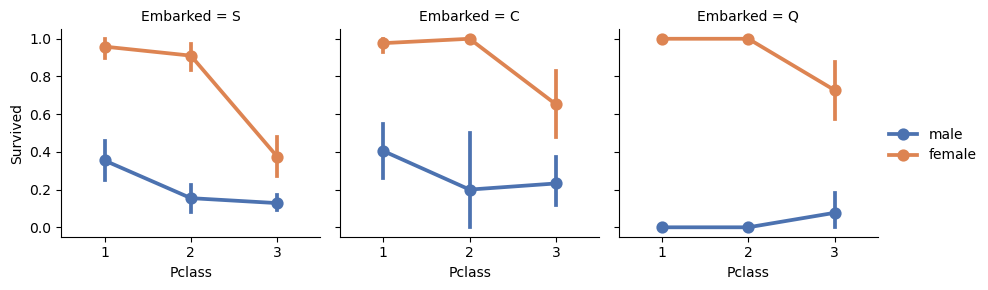

In [15]:
# grid = sns.FacetGrid(train_df, col='Embarked')
grid = sns.FacetGrid(train_df, col='Embarked')
grid.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', palette='deep', hue_order=['male', 'female'])
grid.add_legend()

plt.show()

# Точки на графиках - средняя выживаемость в каждой из группе, линия, соединяющая точки - показывает
# как меняется вероятность на выживание из группы в группу. А вертикальные линии из точек - это доверительный интервал 
# чем больше линия - тем больше разброс значений

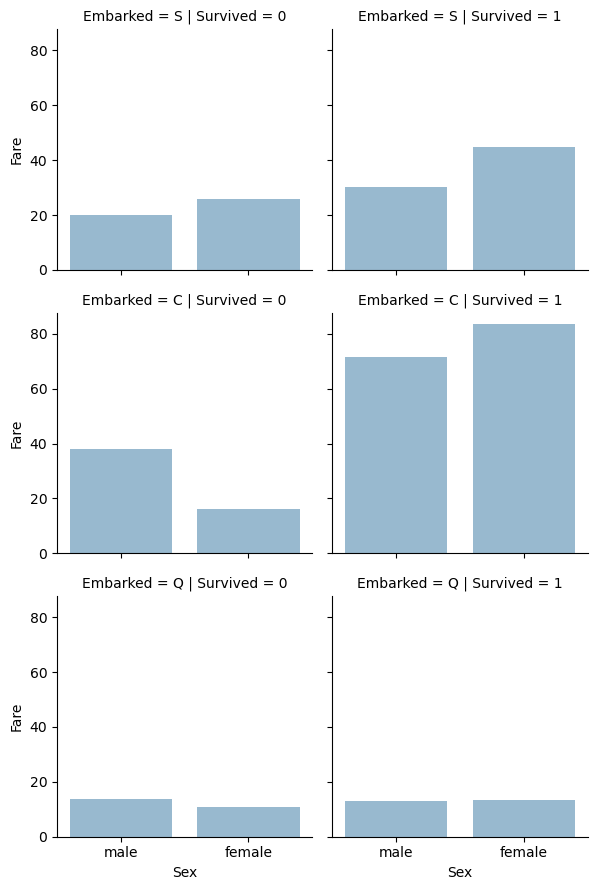

In [16]:
# grid = sns.FacetGrid(train_df, col='Embarked', hue='Survived')
grid = sns.FacetGrid(train_df, row='Embarked', col='Survived',)
grid.map(sns.barplot, 'Sex', 'Fare', alpha=.5, errorbar=None, order=['male', 'female'], hue_order=['male', 'female'])
grid.add_legend()

plt.show()

# ОБРАБОТКА ДАННЫХ

#### корректировка путем удаления ненужных признаков

In [17]:
print('Before', train_df.shape, test_df.shape, combine[0].shape, combine[1].shape)

train_df = train_df.drop(['Ticket', 'Cabin'], axis=1)
test_df = test_df.drop(['Ticket', 'Cabin'], axis=1)
combine = [train_df, test_df]

print('After', train_df.shape, test_df.shape, combine[0].shape, combine[1].shape)

# Не понял почему в данном случае, столбцы удаяляются по-отдельности а не разом через переменную
# Combine - но ладно, разберусь (Предполагаю, что удалять одновременно для обоих датасетов не лучшая идея)

Before (891, 12) (418, 11) (891, 12) (418, 11)
After (891, 10) (418, 9) (891, 10) (418, 9)


#### Создаем новый признак из уже существующих

In [18]:
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+\\.)', expand=False)

# Заметь, в данном случае, мы создаем колонку - Title - через переменную - combine - т.е для обоих датасетов одновременно

C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


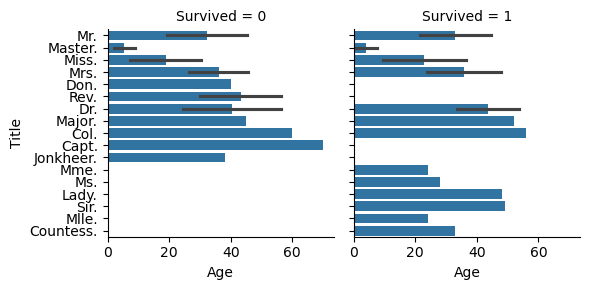

In [19]:
# Визуализируем корреляцию новой фичи - Title - с Целевой Переменной - Survived

grid = sns.FacetGrid(train_df, col='Survived')
grid.map(sns.barplot, 'Age', 'Title', errorbar='sd')

plt.show()

In [20]:
train_df['Title'].value_counts()

Title
Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Mlle.          2
Major.         2
Col.           2
Countess.      1
Capt.          1
Ms.            1
Sir.           1
Lady.          1
Mme.           1
Don.           1
Jonkheer.      1
Name: count, dtype: int64

In [21]:
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady.', 'Countess.','Capt.', 'Col.', 'Don.', 'Dr.', 'Major.', 'Rev.', 'Sir.', 'Jonkheer.', 'Dona.'], 'Rare')

    dataset['Title'] = dataset['Title'].replace(['Mlle.', 'Ms.'], 'Miss.')
    dataset['Title'] = dataset['Title'].replace('Mme.', 'Mrs.')

train_df[['Title', 'Survived']].groupby(['Title'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Title,Survived
3,Mrs.,0.793651
1,Miss.,0.702703
0,Master.,0.575000
4,Rare,0.347826
2,Mr.,0.156673


In [22]:
title_mapping = {'Mr.': 1, 'Miss.': 2, 'Mrs.': 3, 'Master.': 4, 'Rare': 5}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)

In [23]:
train_df['Title'].unique()

array([1, 3, 2, 4, 5], dtype=int64)

In [24]:
train_df = train_df.drop(['Name', 'PassengerId'], axis=1)
test_df = test_df.drop(['Name'], axis=1)
combine = [train_df, test_df]

train_df.shape, test_df.shape

((891, 9), (418, 9))

#### Преобразуем Категориальные Признаки в Количественный тип

In [25]:
for dataset in combine:
    dataset['Sex'] = dataset['Sex'].map({'female': 1, 'male': 0})

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22.0,1,0,7.2500,S,1
1,1,1,1,38.0,1,0,71.2833,C,3
2,1,3,1,26.0,0,0,7.9250,S,2
3,1,1,1,35.0,1,0,53.1000,S,3
4,0,3,0,35.0,0,0,8.0500,S,1


#### Дополнение фич, с количественным непрерывным типом данных

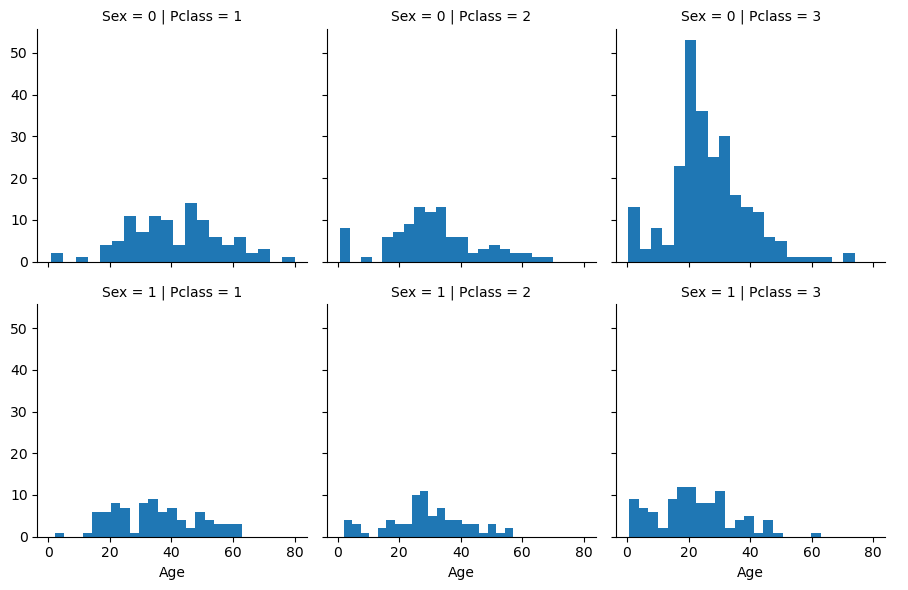

In [26]:
# grid = sns.FacetGrid(train_df, col='Pclass', hue='Sex')
grid = sns.FacetGrid(train_df, row='Sex', col='Pclass')
grid.map(plt.hist, 'Age', bins=20)
grid.add_legend()

plt.show()

In [27]:
# Сначала вычисляем медианные значения для Age по группам (Sex, Pclass)
guess_ages = train_df.groupby(['Sex', 'Pclass'])['Age'].median().to_dict()

# Заполняем пропущенные значения в Age на основе медианных значений
for dataset in combine:
    dataset['Age'] = dataset.apply(
        lambda row: guess_ages.get((row['Sex'], row['Pclass']), row['Age']) if pd.isna(row['Age']) else row['Age'],
        axis=1
    )
    
    # Преобразуем Age в int
    dataset['Age'] = dataset['Age'].astype(int)

In [28]:
test_df['Age'].isnull().sum(), train_df['Age'].isnull().sum()

(0, 0)

In [29]:
train_df['Age_band'] = pd.cut(train_df['Age'], 5)
train_df[['Age_band', 'Survived']].groupby('Age_band', as_index=False, observed=False).mean().sort_values(by='Age_band', ascending=True)

,Age_band,Survived
0,"(-0.08, 16.0]",0.550000
1,"(16.0, 32.0]",0.337374
2,"(32.0, 48.0]",0.412037
3,"(48.0, 64.0]",0.434783
4,"(64.0, 80.0]",0.090909


In [30]:
for dataset in combine:
    dataset.loc[dataset['Age'] <= 16, 'Age'] = 0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[dataset['Age'] > 64, 'Age'] 

train_df.head()




# Вместо кода сверху, можно использовать боелее простой вариант:

# bins = [0, 16, 32, 48, 64, np.inf]  # Границы возрастных категорий
# labels = [0, 1, 2, 3, 4]  # Метки для категорий

# for dataset in combine:
#     dataset['Age'] = pd.cut(dataset['Age'], bins=bins, labels=labels, right=False)  # right=False исключает правую границу

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Age_band
0,0,3,0,1,1,0,7.2500,S,1,"(16.0, 32.0]"
1,1,1,1,2,1,0,71.2833,C,3,"(32.0, 48.0]"
2,1,3,1,1,0,0,7.9250,S,2,"(16.0, 32.0]"
3,1,1,1,2,1,0,53.1000,S,3,"(32.0, 48.0]"
4,0,3,0,2,0,0,8.0500,S,1,"(32.0, 48.0]"


In [31]:
train_df = train_df.drop(['Age_band'], axis=1)
combine = [train_df, test_df]

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,1,1,0,7.2500,S,1
1,1,1,1,2,1,0,71.2833,C,3
2,1,3,1,1,0,0,7.9250,S,2
3,1,1,1,2,1,0,53.1000,S,3
4,0,3,0,2,0,0,8.0500,S,1


In [32]:
for dataset in combine:
    dataset['Family_size'] = dataset['SibSp'] + dataset['Parch'] + 1

train_df[['Family_size', 'Survived']].groupby(['Family_size'], as_index=False).mean().sort_values(by='Survived', ascending=False)


# dataset['SibSp'] + dataset['Parch'] + 1 - добавляем 1, чтобы учитывать самого пассажира - который без родителей и родственников

,Family_size,Survived
3,4,0.724138
2,3,0.578431
1,2,0.552795
6,7,0.333333
0,1,0.303538
4,5,0.200000
5,6,0.136364
7,8,0.000000
8,11,0.000000


In [33]:
for dataset in combine:
    dataset['Is_alone'] = 0
    dataset.loc[dataset['Family_size'] == 1, 'Is_alone'] = 1

train_df[['Is_alone', 'Survived']].groupby(['Is_alone'], as_index=False).mean()

,Is_alone,Survived
0,0,0.505650
1,1,0.303538


In [34]:
train_df = train_df.drop(columns=['SibSp', 'Parch', 'Family_size'])
test_df = test_df.drop(columns=['SibSp', 'Parch', 'Family_size'])
combine = [train_df, test_df]

train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,Is_alone
0,0,3,0,1,7.2500,S,1,0
1,1,1,1,2,71.2833,C,3,0
2,1,3,1,1,7.9250,S,2,1
3,1,1,1,2,53.1000,S,3,0
4,0,3,0,2,8.0500,S,1,1


In [35]:
for dataset in combine:
    dataset['Age*Pclass'] = dataset.Age * dataset.Pclass

train_df.loc[:, ['Age*Pclass', 'Age', 'Pclass']].head(10)

,Age*Pclass,Age,Pclass
0,3,1,3
1,2,2,1
2,3,1,3
3,2,2,1
4,6,2,3
5,3,1,3
6,3,3,1
7,0,0,3
8,3,1,3
9,0,0,2


In [36]:
freq_port = train_df.Embarked.dropna().mode()[0]
freq_port

'S'

In [37]:
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].fillna(freq_port)

train_df[['Embarked', 'Survived']].groupby(['Embarked'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


In [38]:
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,Is_alone,Age*Pclass
0,0,3,0,1,7.2500,0,1,0,3
1,1,1,1,2,71.2833,1,3,0,2
2,1,3,1,1,7.9250,0,2,1,3
3,1,1,1,2,53.1000,0,3,0,2
4,0,3,0,2,8.0500,0,1,1,6


In [39]:
test_df['Fare'].isna().sum()

1

In [40]:
test_df.fillna({'Fare': test_df['Fare'].dropna().median()}, inplace=True)
test_df['Fare'].isna().sum()

0

In [41]:
train_df['Fare_band'] = pd.qcut(train_df['Fare'], 4)
train_df[['Fare_band', 'Survived']].groupby(['Fare_band'], as_index=False).mean().sort_values(by='Survived', ascending=False)

C:\Users\User\AppData\Local\Temp\ipykernel_25256\1111191976.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df[['Fare_band', 'Survived']].groupby(['Fare_band'], as_index=False).mean().sort_values(by='Survived', ascending=False)


,Fare_band,Survived
3,"(31.0, 512.329]",0.581081
2,"(14.454, 31.0]",0.454955
1,"(7.91, 14.454]",0.303571
0,"(-0.001, 7.91]",0.197309


In [42]:
for dataset in combine:
    dataset.loc[dataset['Fare'] <= 7.91, 'Fare'] = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31.0), 'Fare'] = 2
    dataset.loc[dataset['Fare'] > 31.0, 'Fare'] = 3
    dataset['Fare'] = dataset['Fare'].astype(int)

train_df = train_df.drop(['Fare_band'], axis=1)
combine = [train_df, test_df]

In [43]:
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,Is_alone,Age*Pclass
0,0,3,0,1,0,0,1,0,3
1,1,1,1,2,3,1,3,0,2
2,1,3,1,1,1,0,2,1,3
3,1,1,1,2,3,0,3,0,2
4,0,3,0,2,1,0,1,1,6


# Моделирование, Предсказание и Решение

In [44]:
X_train = train_df.drop('Survived', axis=1)
y_train = train_df['Survived']

X_test = test_df.drop('PassengerId', axis=1).copy()

# использование .copy() для X_test — это мера предосторожности, чтобы избежать побочных эффектов изменения данных в других частях кода.

#### Логистическая Регрессия

In [45]:
# Logistic Regression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
acc_log = round(logreg.score(X_train, y_train)*100, 2)
acc_log

80.36

In [46]:
coeff_df = pd.DataFrame(train_df.columns.delete(0))
coeff_df.columns = ['Feature']
coeff_df['Correlation'] = pd.Series(logreg.coef_[0])

coeff_df.sort_values(by='Correlation', ascending=False)

# logreg.coef_[0] - коэффициент вклада каждого из признаков (очень похоже на корреляцию но это не она
# эти коэффициенты показывают как изменение признака влияет на логарифм отношения вероятностей log-odds - 
# полож.коэфф - полож.зависимость, отриц.коэфф - отриц.зависимость. Чем больше (ПО МОДУЛЮ) коэфф. - тем сильнее влияние признака

,Feature,Correlation
1,Sex,2.201445
5,Title,0.397484
2,Age,0.286911
4,Embarked,0.261583
6,Is_alone,0.126942
3,Fare,-0.086368
7,Age*Pclass,-0.310963
0,Pclass,-0.750392


#### Support Vector Machines (SVM)

In [53]:
# Support Vector Machines - RBF kernel

svc = SVC()
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
acc_svc = round(svc.score(X_train, y_train)*100, 2)
acc_svc

78.23

In [54]:
# Support Vector Machines - Linear kernel

linear_svc = LinearSVC()
linear_svc.fit(X_train, y_train)
y_pred = linear_svc.predict(X_test)
acc_linear_svc = round(linear_svc.score(X_train, y_train)*100, 2)
acc_linear_svc

78.9

#### k-Nearest Neighbors (k-NN)

In [50]:
# k-Nearest Neighbors

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc_knn = round(knn.score(X_train, y_train)*100, 2)
acc_knn

83.84

#### Gaussian Naive Bayes

In [51]:
# Gaussian Naive Bayes

gaussian = GaussianNB()
gaussian.fit(X_train, y_train)
y_pred = gaussian.predict(X_test)
acc_gaussian = round(gaussian.score(X_train, y_train)*100, 2)
acc_gaussian

72.28

#### Perceptron

In [52]:
# Perceptron

perceptron = Perceptron()
perceptron.fit(X_train, y_train)
y_pred = perceptron.predict(X_test)
acc_perceptron = round(perceptron.score(X_train, y_train)*100, 2)
acc_perceptron

78.34

#### Градиентный Спуск

In [55]:
# Stochastic Gradient Descent

sgd = SGDClassifier()
sgd.fit(X_train, y_train)
y_pred = sgd.predict(X_test)
acc_sgd = round(sgd.score(X_train, y_train)*100, 2)
acc_sgd

73.18

#### Decision Tree - Дерево Решений

In [57]:
# Decision Tree

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
y_rped = decision_tree.predict(X_test)
acc_decision_tree = round(decision_tree.score(X_train, y_train)*100, 2)
acc_decision_tree

86.76

#### Random Forest - Случайный Лес

In [58]:
# Random Forest

random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)
y_pred = random_forest.predict(X_test)
acc_random_forest = round(random_forest.score(X_train, y_train)*100, 2)
acc_random_forest

86.76

# Model Evaluation - Оценка Моеделей

In [60]:
models = pd.DataFrame({
    'Model': ['Support Vector Machines', 'KNN', 'Logistic Regression', 
              'Random Forest', 'Naive Bayes', 'Perceptron', 
              'Stochastic Gradient Decent', 'Linear SVC', 
              'Decision Tree'],
    'Score': [acc_svc, acc_knn, acc_log, 
              acc_random_forest, acc_gaussian, acc_perceptron, 
              acc_sgd, acc_linear_svc, acc_decision_tree]
})

models.sort_values(by='Score', ascending=False)

,Model,Score
3,Random Forest,86.76
8,Decision Tree,86.76
1,KNN,83.84
2,Logistic Regression,80.36
7,Linear SVC,78.90
5,Perceptron,78.34
0,Support Vector Machines,78.23
6,Stochastic Gradient Decent,73.18
4,Naive Bayes,72.28


In [62]:
submission = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": y_pred
    })
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
